# LieselOptim: advanced multi-size optimization

This notebook repeats the basic `LieselOptim` workflow with a model that has multiple observed branches. The branches have different sample sizes and use different observation axes. We use a train/validation/test split, mini-batches, early stopping, two optimizers that own disjoint parameter blocks, and a learning-rate scheduler.

## Imports

In [1]:
import logging

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.experimental.optim as opt
import liesel.model as lsl

logging.getLogger("liesel.model.model").setLevel(logging.WARNING)
pd.options.display.float_format = "{:.3f}".format

## Simulate two observed branches

The first branch is a standard regression with sample size `n_main = 360` along axis `0`. The second branch is a panel-like likelihood with four series and `n_panel = 180` observations per series along axis `1`. This means the optimizer must split and batch `X_main` and `y_main` along axis `0`, but `t_panel` and `z_panel` along axis `1`.

In [2]:
rng = np.random.default_rng(202406)

n_main = 360
x1 = rng.normal(size=n_main).astype("float32")
x2 = rng.uniform(-1.0, 1.0, size=n_main).astype("float32")
X_main = np.column_stack([np.ones(n_main, dtype="float32"), x1, x2]).astype("float32")

beta_true = np.array([0.5, 1.0, -0.7], dtype="float32")
sigma_y_true = np.float32(0.7)
y_main = (X_main @ beta_true + rng.normal(scale=sigma_y_true, size=n_main)).astype("float32")

n_series = 4
n_panel = 180
time_grid = np.linspace(-1.0, 1.0, n_panel, dtype="float32")
t_panel = np.tile(time_grid, (n_series, 1)).astype("float32")

alpha_true = np.array([-0.8, -0.2, 0.4, 1.1], dtype="float32")
gamma_true = np.float32(-1.2)
sigma_z_true = np.float32(0.35)
z_panel = (
    alpha_true[:, None]
    + gamma_true * t_panel
    + rng.normal(scale=sigma_z_true, size=(n_series, n_panel))
).astype("float32")

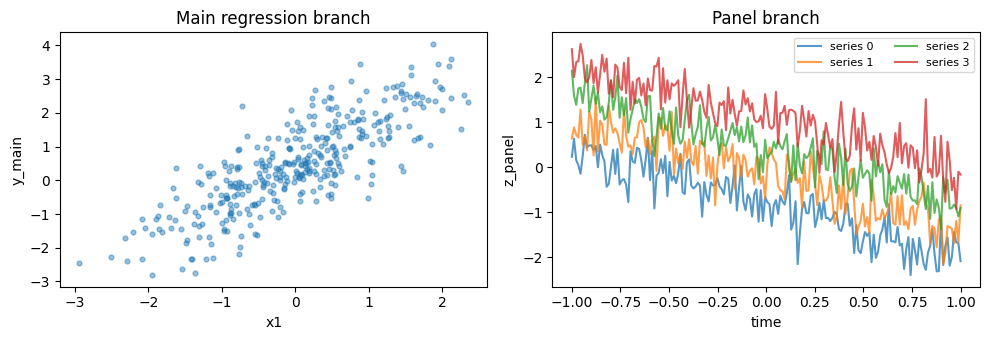

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].scatter(X_main[:, 1], y_main, s=12, alpha=0.45)
axes[0].set_xlabel("x1")
axes[0].set_ylabel("y_main")
axes[0].set_title("Main regression branch")

for series in range(n_series):
    axes[1].plot(time_grid, z_panel[series], alpha=0.75, label=f"series {series}")
axes[1].set_xlabel("time")
axes[1].set_ylabel("z_panel")
axes[1].set_title("Panel branch")
axes[1].legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

## Build a multi-branch model

The two likelihood branches share one Liesel model but use separate parameter blocks. The main branch owns `beta` and `log_sigma_y`; the panel branch owns `alpha`, `gamma`, and `log_sigma_z`.

In [4]:
X_main_jax = jnp.asarray(X_main)
y_main_jax = jnp.asarray(y_main)
t_panel_jax = jnp.asarray(t_panel)
z_panel_jax = jnp.asarray(z_panel)

beta = lsl.Var.new_param(
    jnp.zeros(X_main_jax.shape[1]),
    lsl.Dist(tfd.Normal, loc=0.0, scale=5.0),
    name="beta",
)
log_sigma_y = lsl.Var.new_param(
    jnp.array(0.0),
    lsl.Dist(tfd.Normal, loc=0.0, scale=1.0),
    name="log_sigma_y",
)
sigma_y = lsl.Var.new_calc(jnp.exp, log_sigma_y, name="sigma_y")
X = lsl.Var.new_obs(X_main_jax, name="X_main")
mu_y = lsl.Var.new_calc(lambda X, beta: X @ beta, X, beta, name="mu_y")
y = lsl.Var.new_obs(
    y_main_jax,
    lsl.Dist(tfd.Normal, loc=mu_y, scale=sigma_y),
    name="y_main",
)

alpha = lsl.Var.new_param(
    jnp.zeros(z_panel_jax.shape[0]),
    lsl.Dist(tfd.Normal, loc=0.0, scale=3.0),
    name="alpha",
)
gamma = lsl.Var.new_param(
    jnp.array(0.0),
    lsl.Dist(tfd.Normal, loc=0.0, scale=3.0),
    name="gamma",
)
log_sigma_z = lsl.Var.new_param(
    jnp.array(0.0),
    lsl.Dist(tfd.Normal, loc=0.0, scale=1.0),
    name="log_sigma_z",
)
sigma_z = lsl.Var.new_calc(jnp.exp, log_sigma_z, name="sigma_z")
t = lsl.Var.new_obs(t_panel_jax, name="t_panel")
mu_z = lsl.Var.new_calc(
    lambda alpha, gamma, t: alpha[:, None] + gamma * t,
    alpha,
    gamma,
    t,
    name="mu_z",
)
z = lsl.Var.new_obs(
    z_panel_jax,
    lsl.Dist(tfd.Normal, loc=mu_z, scale=sigma_z),
    name="z_panel",
)

model = lsl.Model([y, z])
{
    "parameters": list(model.parameters),
    "observed": list(model.observed),
}

{'parameters': ['log_sigma_z', 'gamma', 'alpha', 'log_sigma_y', 'beta'],
 'observed': ['t_panel', 'X_main', 'z_panel', 'y_main']}

## Split with branch-specific axes

The `axes` mapping tells the split and batch utilities where the observation dimension lives. Observed variables not listed in `axes` use `default_axis=0`. Because the branches have different sample sizes, `multi_size="manager"` returns a `PositionSplitManager`.

In [5]:
axes = {"t_panel": 1, "z_panel": 1}
observed_keys = ["X_main", "y_main", "t_panel", "z_panel"]

split = opt.PositionSplit.from_model(
    model,
    position_keys=observed_keys,
    share_validate=0.2,
    share_test=0.1,
    axes=axes,
    default_axis=0,
    shuffle=True,
    seed=123,
    multi_size="manager",
)

split

PositionSplitManager(n=(360, 180), train=(252, 126), validate=(72, 36), test=(36, 18))

In [6]:
pd.DataFrame(
    [
        {
            "keys": ", ".join(child.position_keys),
            "n": child.n,
            "train": child.n_train,
            "validate": child.n_validate,
            "test": child.n_test,
        }
        for child in split.splits
    ]
)

,keys,n,train,validate,test
0,"X_main, y_main",360,252,72,36
1,"t_panel, z_panel",180,126,36,18


## Two optimizers and a learning-rate scheduler

`OptimEngine` can run several optimizers in sequence for every batch. Their `position_keys` must be disjoint. Here, the main regression parameters use Adam with gradient clipping and an exponential-decay schedule. The panel parameters use a separate Adam optimizer with a fixed learning rate.

In [7]:
main_schedule = optax.exponential_decay(
    init_value=2e-2,
    transition_steps=25,
    decay_rate=0.9,
    end_value=2e-4,
)

main_optimizer = opt.Optimizer(
    ["beta", "log_sigma_y"],
    optax.chain(optax.clip_by_global_norm(10.0), optax.adam(main_schedule)),
    identifier="main_adam",
)
panel_optimizer = opt.Optimizer(
    ["alpha", "gamma", "log_sigma_z"],
    optax.adam(learning_rate=5e-3),
    identifier="panel_adam",
)

pd.DataFrame(
    {
        "step": [0, 25, 50, 100, 200],
        "main_learning_rate": [float(main_schedule(step)) for step in [0, 25, 50, 100, 200]],
    }
)

,step,main_learning_rate
0,0,0.020
1,25,0.018
2,50,0.016
3,100,0.013
4,200,0.009


## Build and inspect the engine

Passing the `PositionSplitManager` to `LieselOptim` makes the batching side use a `BatchManager`. The same `axes` mapping is passed again so the panel arrays are batched along axis `1`.

In [8]:
engine = opt.LieselOptim(
    model,
    split=split,
    batch_size=42,
    axes=axes,
    default_axis=0,
    optimizers=[main_optimizer, panel_optimizer],
    stopper=opt.Stopper(epochs=300, patience=35, rtol=5e-4),
    seed=321,
).build_engine()
engine.show_progress = False

{
    "batching": repr(engine.batches),
    "n": engine.batches.n,
    "batch_size": engine.batches.batch_size,
    "n_full_batches": engine.batches.n_full_batches,
    "optimizer_ids": [optimizer.identifier for optimizer in engine.optimizers],
}

{'batching': "BatchManager(n=(252, 126), batch_size=(42, 42), mode='resample', n_full_batches=6)",
 'n': (252, 126),
 'batch_size': (42, 42),
 'n_full_batches': 6,
 'optimizer_ids': ['main_adam', 'panel_adam']}

The `BatchManager` forms a joint epoch from branch-specific mini-batches. With `mode="resample"`, the shorter branch can reuse child batch rows so that all optimizer blocks still see a joint batch at every step.

In [9]:
result = engine.fit()
result

OptimResult(final_epoch=96, best_epoch=62, duration=1.0s)

## Inspect the fitted parameters

In [10]:
position = result.best_position

rows = [
    {
        "parameter": f"beta[{i}]",
        "estimate": float(position["beta"][i]),
        "truth": float(truth),
    }
    for i, truth in enumerate(beta_true)
]
rows += [
    {
        "parameter": f"alpha[{i}]",
        "estimate": float(position["alpha"][i]),
        "truth": float(truth),
    }
    for i, truth in enumerate(alpha_true)
]
rows += [
    {
        "parameter": "gamma",
        "estimate": float(position["gamma"]),
        "truth": float(gamma_true),
    },
    {
        "parameter": "sigma_y",
        "estimate": float(jnp.exp(position["log_sigma_y"])),
        "truth": float(sigma_y_true),
    },
    {
        "parameter": "sigma_z",
        "estimate": float(jnp.exp(position["log_sigma_z"])),
        "truth": float(sigma_z_true),
    },
]

pd.DataFrame(rows)

,parameter,estimate,truth
0,beta[0],0.481,0.500
1,beta[1],1.042,1.000
2,beta[2],-0.592,-0.700
3,alpha[0],-0.793,-0.800
4,alpha[1],-0.177,-0.200
5,alpha[2],0.440,0.400
6,alpha[3],1.088,1.100
7,gamma,-1.219,-1.200
8,sigma_y,0.715,0.700
9,sigma_z,0.339,0.350


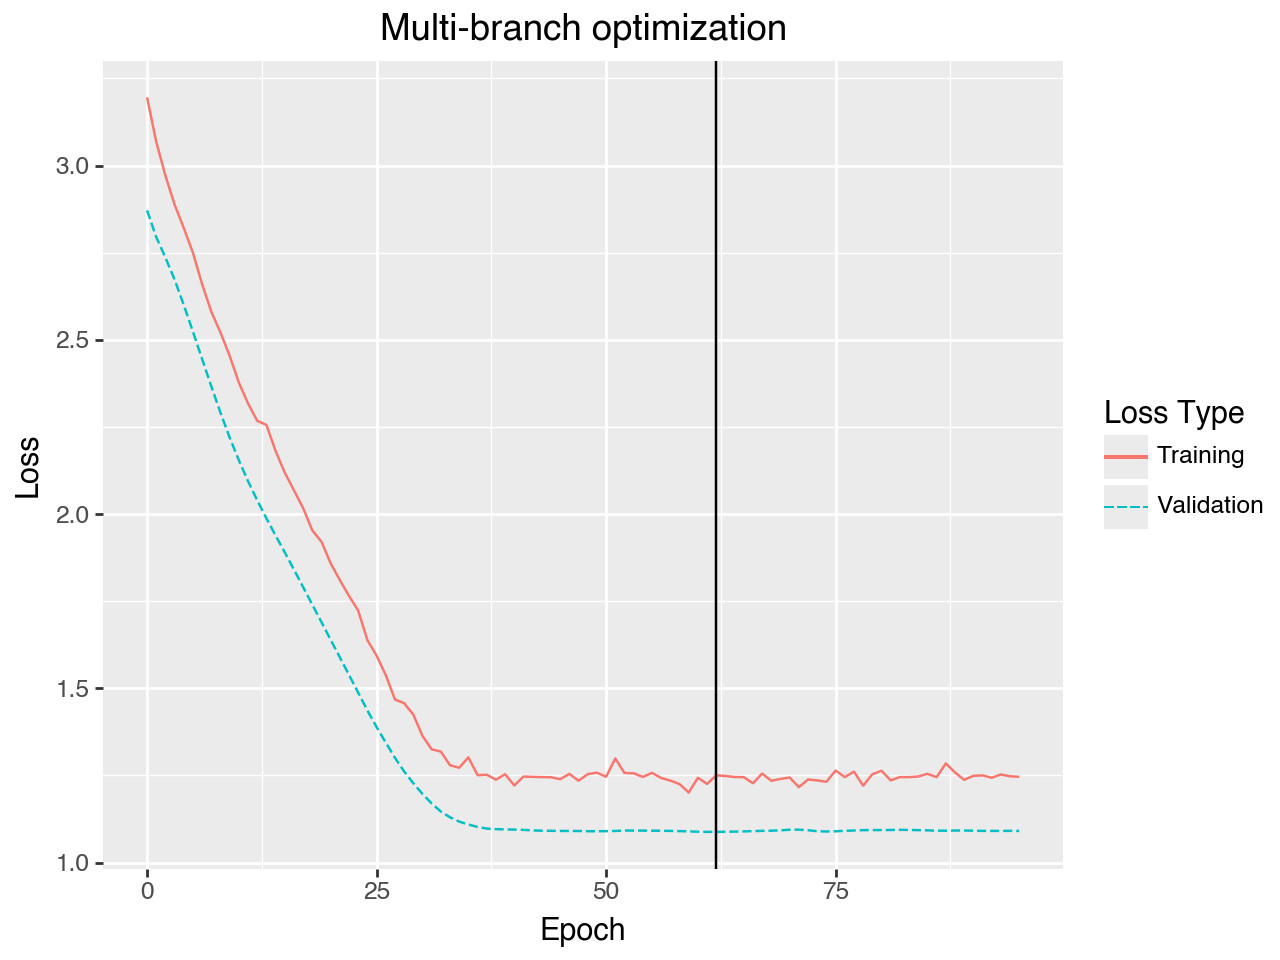

In [11]:
result.plot_loss(title="Multi-branch optimization")

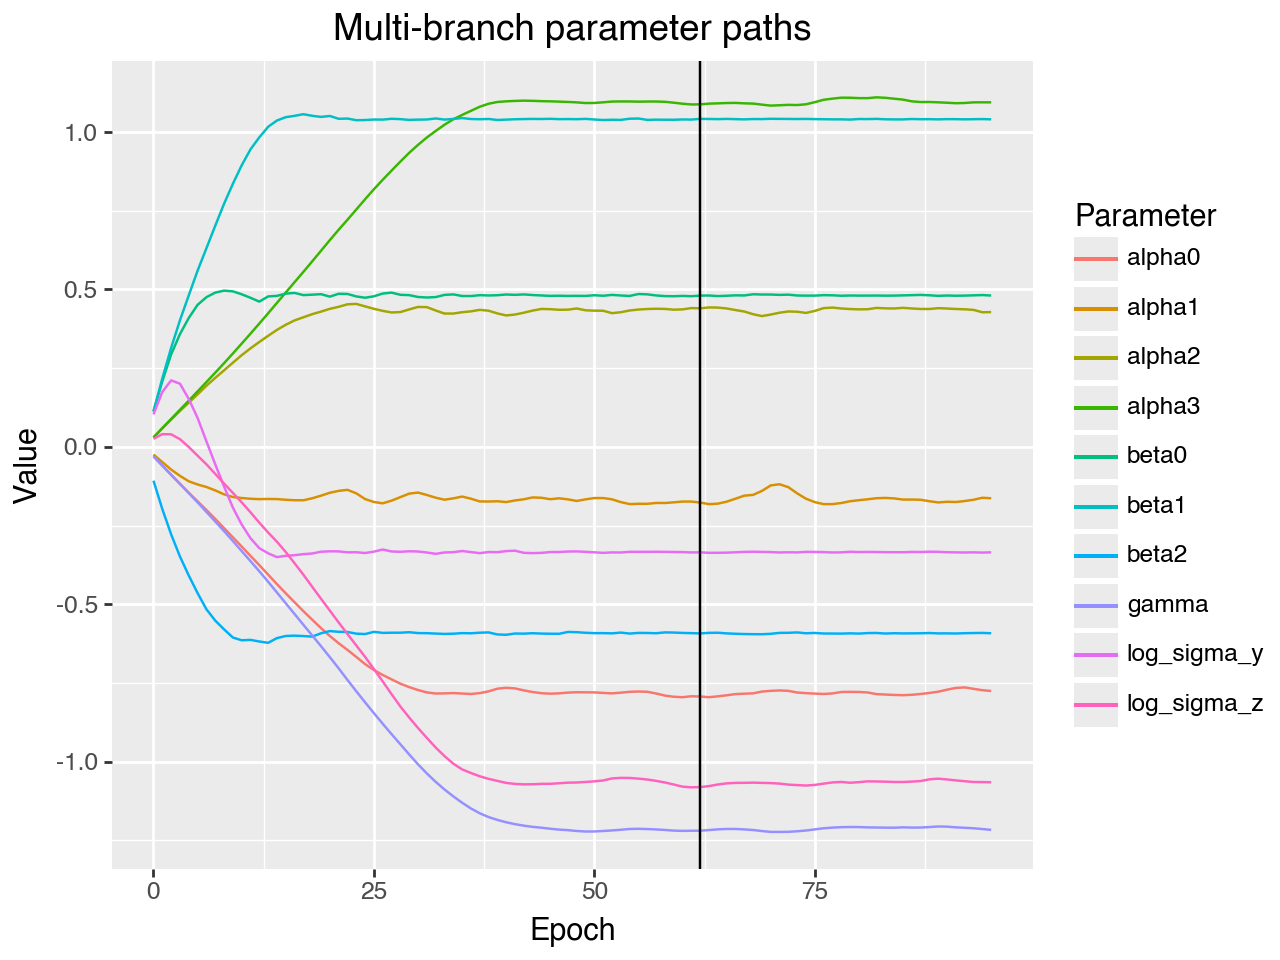

In [12]:
result.plot_params(
    title="Multi-branch parameter paths",
    subset=["beta", "alpha", "gamma", "log_sigma_y", "log_sigma_z"],
)

## Held-out test loss

For a `PositionSplitManager`, `scaled_log_lik()` applies the correct branch-specific scaling internally. The scalar used by the default scaled loss is the total training size across branches.

In [13]:
test_state = model.update_state(result.best_position | split.test, model.state)
test_loss = float(
    -split.scaled_log_lik(model, test_state, part="test") / sum(split.n_trains)
)

pd.DataFrame(
    {
        "best_epoch": [result.best_epoch],
        "final_epoch": [result.final_epoch],
        "test_loss": [test_loss],
    }
)

,best_epoch,final_epoch,test_loss
0,62,96,1.339


## Predictions by branch

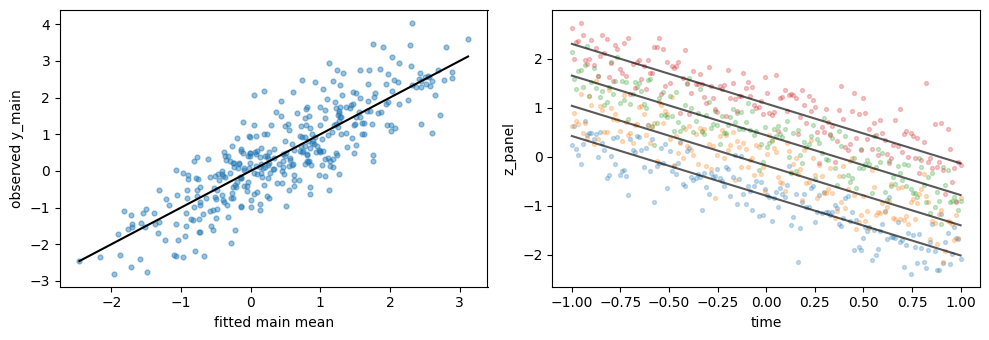

In [14]:
position = result.best_position

beta_hat = np.asarray(position["beta"])
main_hat = X_main @ beta_hat

alpha_hat = np.asarray(position["alpha"])
gamma_hat = float(position["gamma"])
panel_hat = alpha_hat[:, None] + gamma_hat * t_panel

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].scatter(main_hat, y_main, s=12, alpha=0.45)
axes[0].plot([main_hat.min(), main_hat.max()], [main_hat.min(), main_hat.max()], color="black")
axes[0].set_xlabel("fitted main mean")
axes[0].set_ylabel("observed y_main")

for series in range(n_series):
    axes[1].scatter(time_grid, z_panel[series], s=8, alpha=0.25)
    axes[1].plot(time_grid, panel_hat[series], color="black", alpha=0.65)
axes[1].set_xlabel("time")
axes[1].set_ylabel("z_panel")
plt.tight_layout()
plt.show()